# Đọc dữ liệu đã xử lý

In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/processed_data.csv')
print(df.shape)
df.head()

(28587, 24)


,Area,Floors,Bedrooms,Bathrooms,Price,Legal status_Sale contract,City_Bình Dương,City_Bình Thuận,City_Bắc Ninh,City_Cần Thơ,...,City_Khánh Hòa,City_Kiên Giang,City_Long An,City_Lâm Đồng,City_Other,City_Quảng Ninh,City_Thanh Hóa,City_Đà Nẵng,City_Đắk Lắk,City_Đồng Nai
0,84.0,4.0,3.0,3.0,8.60,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,60.0,5.0,3.0,3.0,7.50,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,90.0,5.0,3.0,3.0,8.90,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,54.0,2.0,2.0,3.0,5.35,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,92.0,2.0,4.0,4.0,6.90,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# Tách feature (X) và target (y)

In [47]:
X = df.drop(columns=['Price'])
y = df['Price']

print("Số feature:", X.shape[1])
print(X.columns.tolist())

Số feature: 23
['Area', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status_Sale contract', 'City_Bình Dương', 'City_Bình Thuận', 'City_Bắc Ninh', 'City_Cần Thơ', 'City_Hà Nội', 'City_Hưng Yên', 'City_Hải Phòng', 'City_Hồ Chí Minh', 'City_Khánh Hòa', 'City_Kiên Giang', 'City_Long An', 'City_Lâm Đồng', 'City_Other', 'City_Quảng Ninh', 'City_Thanh Hóa', 'City_Đà Nẵng', 'City_Đắk Lắk', 'City_Đồng Nai']


# Chia train/test

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train Price - mean:", y_train.mean(), "std:", y_train.std())
print("Test Price - mean:", y_test.mean(), "std:", y_test.std())

Train shape: (22869, 23)
Test shape: (5718, 23)
Train Price - mean: 5.865110848747213 std: 2.1977493620411344
Test Price - mean: 5.84609129066107 std: 2.1672596366731285


## Train model Linear Regression

In [49]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Đã train xong model")

Đã train xong model


In [50]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)
print("\nIntercept:", model.intercept_)

                       Feature  Coefficient
10               City_Hưng Yên     2.007616
12            City_Hồ Chí Minh     1.513309
9                  City_Hà Nội     1.464960
16               City_Lâm Đồng     1.024590
1                       Floors     0.513103
20                City_Đà Nẵng     0.258695
3                    Bathrooms     0.180707
2                     Bedrooms     0.113989
0                         Area     0.040483
8                 City_Cần Thơ     0.021037
4   Legal status_Sale contract    -0.003345
13              City_Khánh Hòa    -0.090950
18             City_Quảng Ninh    -0.096075
11              City_Hải Phòng    -0.407377
7                City_Bắc Ninh    -0.439146
17                  City_Other    -1.182029
5              City_Bình Dương    -1.295206
19              City_Thanh Hóa    -1.424636
6              City_Bình Thuận    -1.491973
22               City_Đồng Nai    -1.640987
21                City_Đắk Lắk    -1.687192
14             City_Kiên Giang  

## Đánh giá Model bằng số liệu

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.3f} tỷ")
print(f"RMSE: {rmse:.3f} tỷ")
print(f"R²:   {r2:.3f}")

MAE:  1.352 tỷ
RMSE: 1.690 tỷ
R²:   0.392


# Phân tích các chỉ số (Metrics)
R² = 0.392 (39.2%): Đây là hệ số xác định. Nó có nghĩa là mô hình của bạn chỉ giải thích được khoảng 39.2% sự biến động của giá nhà dựa trên các đặc trưng hiện có (Diện tích, Số phòng, Vị trí...). Điểm số này khá thấp (thông thường một mô hình tốt cần R² > 0.6). Một số lý do có thể kể đến là việc khi ta lựa chọn feautures, để cố đơn giản hóa mô hình, ta đã loại bỏ đi rất  nhiều features mà trên thực tế có thể ảnh hướng lớn tới giá cả chẳng hạn như Acess road hay Frontage. Bên cạnh đó, việc gom nhóm và phân loại cũng còn nhiều yếu tố chủ quan của người thực hiện gây ảnh hưởng tới mô hình.

MAE = 1.352 tỷ: Trung bình, mỗi lần dự đoán, mô hình của bạn báo giá lệch so với thực tế khoảng 1.35 tỷ VNĐ. Với những căn nhà 2-3 tỷ thì sai số này là rất lớn, nhưng với nhà 8-10 tỷ thì có thể chấp nhận được.

RMSE = 1.690 tỷ: Con số này cao hơn MAE một chút, chứng tỏ trong tập Test vẫn còn những căn nhà bị dự đoán sai lệch rất mạnh (outliers trong tập test).

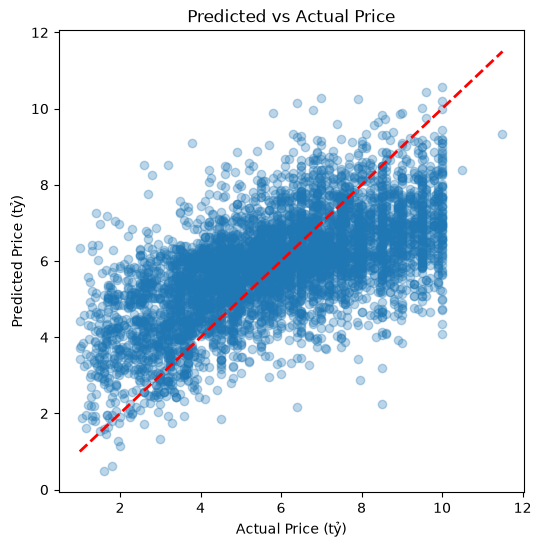

In [52]:
# Biểu đồ Predicted vs Actual
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (tỷ)')
plt.ylabel('Predicted Price (tỷ)')
plt.title('Predicted vs Actual Price')
plt.show()

# Lưu lại Model

In [53]:
import joblib

# Lưu model chính thức (bản gốc, không log-transform)
joblib.dump(model, '../model.pkl')
print("Đã lưu model.pkl")

Đã lưu model.pkl


# Tổng hợp kết quả cuối notebook (markdown cell)
Kết quả cuối cùng

| Model | MAE (tỷ) | RMSE (tỷ) | R² |
|---|---|---|---|
| Linear Regression (gốc) | 1.352 | 1.690 | 0.392 |
| Linear Regression (log-transform Price) | 1.376 | 1.759 | 0.341 |

→ Chọn model gốc vì kết quả tốt hơn.
